In [1]:
import numpy as np
from scipy.stats import uniform
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import os
import pandas as pd

In [2]:
version = 'vpce1.3'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
   
# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']

y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

LF_noise = 0.028
data=pd.read_csv(f'in/{file_in}')

In [3]:
x_lf, x_hf, y_lf, y_hf = ([],[],[],[])
row_h=data.index[data['Mode'] == 1]
row_l=data.index[data['Mode'] == 0]

x_hf = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_hf = data.loc[data['Mode']==1.][y_label_sim].to_numpy()

x_lf = data.loc[data['Mode']==0.][x_labels].to_numpy()
y_lf = data.loc[data['Mode']==0.][ y_label_sim].to_numpy()

In [4]:
# Generate synthetic data
np.random.seed(42)
n_samples = 100

In [5]:
data=pd.read_csv("./in/hf_validation_data_v1.2.csv")
x_data = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_true = data.loc[data['Mode']==1.][y_label_sim].to_numpy()


In [6]:
from itertools import product, combinations

In [7]:
# Generate multivariate Legendre polynomial basis with interaction terms
def multivariate_legendre_with_interactions(order, x):
    """Generate multivariate Legendre polynomial basis with interactions."""
    n_samples, n_features = x.shape
    degrees = list(product(range(order + 1), repeat=n_features))
    basis = []
    for degree in degrees:
        term = np.ones(n_samples)
        for i, d in enumerate(degree):
            term *= np.polynomial.legendre.Legendre.basis(d)(x[:, i])
        basis.append(term)
    
    # Add interaction terms
    for i, j in combinations(range(n_features), 2):
        basis.append(x[:, i] * x[:, j])
    
    return np.vstack(basis).T

In [8]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

In [9]:
def cross_validate_order(x_lf, y_lf, x_hf, y_hf, max_order=5):
    errors = []
    kf = KFold(n_splits=5)
    for order in range(1, max_order + 1):
        phi_lf = multivariate_legendre_with_interactions(order, x_lf)
        phi_hf = multivariate_legendre_with_interactions(order, x_hf)

        # Fit LF model
        c_lf = np.linalg.lstsq(phi_lf, y_lf, rcond=None)[0]
        
        y_lf_hf_pred = phi_hf @ c_lf
        delta_hf = y_hf - y_lf_hf_pred

        mse_fold = []
        for train_idx, test_idx in kf.split(x_hf):
            x_train, x_test = x_hf[train_idx], x_hf[test_idx]
            y_train, y_test = y_hf[train_idx], y_hf[test_idx]

            phi_train = multivariate_legendre_with_interactions(order, x_train)
            phi_test = multivariate_legendre_with_interactions(order, x_test)
            
            # Bayesian fit for HF correction
            c_hf = np.linalg.lstsq(phi_train, y_train - phi_train @ c_lf, rcond=None)[0]
            y_pred_fold = phi_test @ c_hf + phi_test @ c_lf
            mse_fold.append(mean_squared_error(y_test, y_pred_fold))
        
        errors.append(np.mean(mse_fold))
    return np.argmin(errors) + 1

In [10]:
# Cross-validate for optimal polynomial order
optimal_order = cross_validate_order(x_lf, y_lf, x_hf, y_hf, max_order=5)
print(f"Optimal Polynomial Order: {optimal_order}")

Optimal Polynomial Order: 1


In [11]:
from itertools import combinations_with_replacement
from numpy.polynomial.legendre import Legendre

In [12]:
def multivariate_legendre_basis(degree, x_data):
    """
    Generate the multivariate Legendre basis for multi-dimensional inputs.
    
    Parameters:
        x_data (ndarray): Input data of shape (n_samples, n_dim).
        degree (int): Maximum polynomial degree.
    
    Returns:
        basis_matrix (ndarray): Shape (n_samples, n_terms).
    """
    n_samples, n_dim = x_data.shape
    terms = []
    
    # Generate all combinations of terms up to the given degree
    for deg in range(degree + 1):
        for combo in combinations_with_replacement(range(n_dim), deg):
            terms.append(combo)

    # Evaluate each term for all samples
    basis_matrix = np.zeros((n_samples, len(terms)))
    for i, term in enumerate(terms):
        poly = np.prod([Legendre.basis(1)(x_data[:, dim]) for dim in term], axis=0)
        basis_matrix[:, i] = poly

    return basis_matrix

In [13]:
# Define degree of PCE
degree = optimal_order
basis_matrix_hf = multivariate_legendre_basis(degree, x_hf) # Shape: (100, 3)
basis_matrix_lf = multivariate_legendre_basis(degree, x_lf) # Shape: (100, 3)
indices_hf = [299,300,301,302,303,304,305]
# Bayesian model for PCE
with pm.Model() as model:
    # Priors for coefficients for low-fidelity PCE
    coeffs_lf = pm.Normal("coeffs_lf", mu=0, sigma=0.5, shape=basis_matrix_lf.shape[1]) # leave for now
    y_lf_pred_full = pm.Deterministic("y_lf_pred_full", pm.math.dot(basis_matrix_lf, coeffs_lf))  # Low-fidelity PCE
    y_lf_pred_subset = pm.Deterministic("y_lf_pred_subset", y_lf_pred_full[indices_hf])  # Shape: (10,)
    rho = pm.Normal("rho", mu=1, sigma=0.05)  # Prior for scaling factor
    coeffs_delta = pm.Normal("coeffs_delta", mu=0, sigma=0.005, shape=basis_matrix_hf.shape[1])
    delta_pred_from_model = pm.Deterministic("delta_pred", pm.math.dot(basis_matrix_hf, coeffs_delta))
    y_hf_pred = pm.Deterministic("y_hf_pred", rho * y_lf_pred_subset + delta_pred_from_model)

    # Likelihood for high-fidelity data
    sigma_hf = pm.HalfNormal("sigma_hf", sigma=0.01) # leave for now -> improved
    y_like_hf = pm.Normal("y_like_hf", mu=y_hf_pred, sigma=sigma_hf, observed=y_hf)  # Observed high-fidelity data

    # Inference
    #trace = pm.sample(10000, tune=2000, target_accept=0.95, cores=4, return_inferencedata=True, progressbar=True)

    # Inference with Variational Inference
    approx = pm.fit(n=1000000, method="advi", progressbar=True)
    trace = approx.sample(20000)  # Generate samples from the approximation


/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/pymc-env/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 239.04


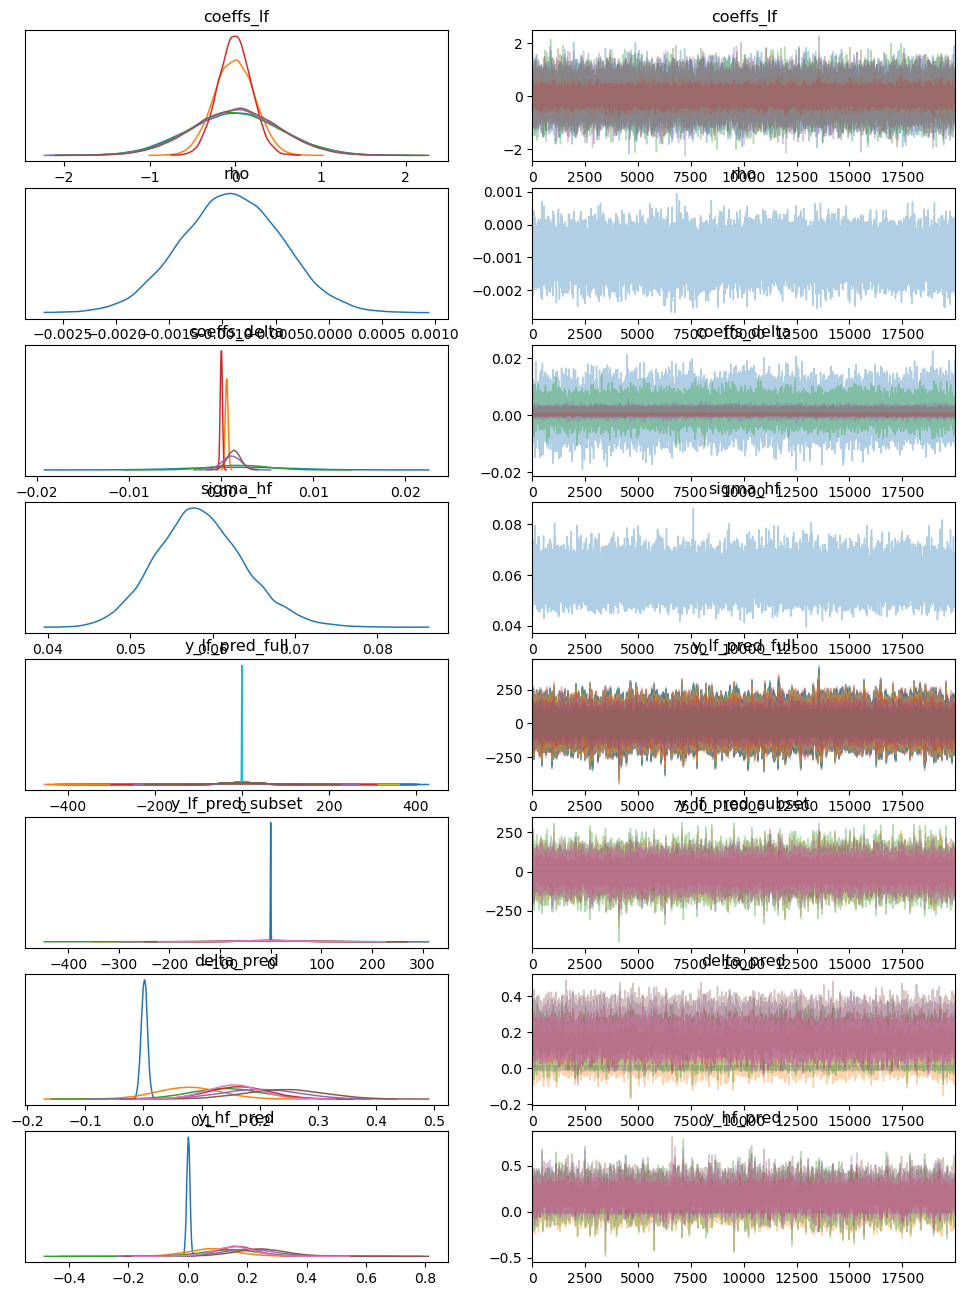

Sampling: []


/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/pymc-env/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [14]:

# Analyze results
az.plot_trace(trace)
plt.show()

# Posterior predictive samples
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_lf_pred_full"])



In [15]:
indices_hf = np.arange(len(x_data))

basis_matrix_hf = multivariate_legendre_basis(degree, x_data) # Shape: (100, 3)
basis_matrix_lf = multivariate_legendre_basis(degree, x_data) # Shape: (100, 3)

# Extract low-fidelity and high-fidelity coefficients from the posterior
coeff_samples_lf = trace.posterior["coeffs_lf"].values  # Shape: (n_chains, n_draws, n_terms_lf)
coeff_samples_delta = trace.posterior["coeffs_delta"].values  # Shape: (n_chains, n_draws, n_terms_hf)
rho_samples = trace.posterior["rho"].values  # Shape: (n_chains, n_draws)

# Flatten coefficients to combine chains and draws
coeff_samples_lf_flat = coeff_samples_lf.reshape(-1, coeff_samples_lf.shape[-1])  # Shape: (n_samples_total, n_terms_lf)
coeff_samples_delta_flat = coeff_samples_delta.reshape(-1, coeff_samples_delta.shape[-1])  # Shape: (n_samples_total, n_terms_hf)
rho_samples_flat = rho_samples.flatten()  # Shape: (n_samples_total,)

# Generate low-fidelity and discrepancy predictions
y_lf_pred_samples = np.dot(coeff_samples_lf_flat, basis_matrix_lf.T)  # Shape: (n_samples_total, n_lf_samples)
delta_pred_samples = np.dot(coeff_samples_delta_flat, basis_matrix_hf.T)  # Shape: (n_samples_total, n_hf_samples)

# Compute high-fidelity predictions at high-fidelity sample locations
y_hf_pred_samples = rho_samples_flat[:, None] * y_lf_pred_samples[:, indices_hf] + delta_pred_samples  # Shape: (n_samples_total, n_hf_samples)

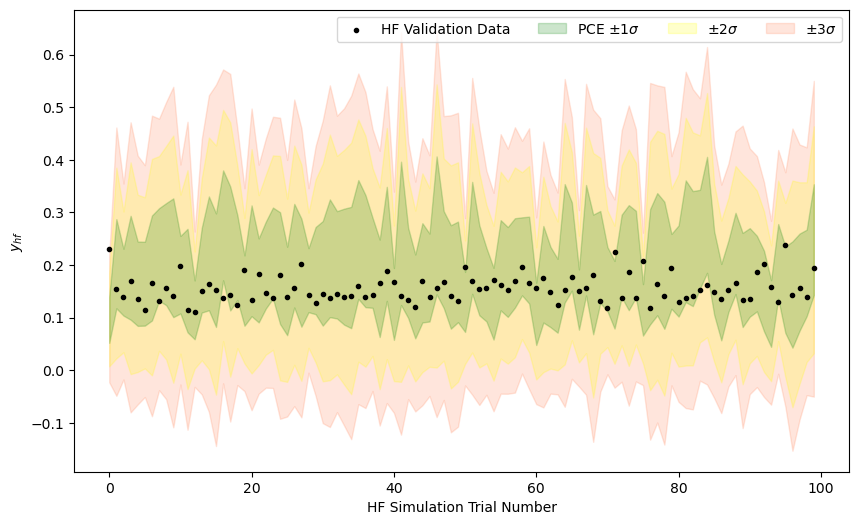

In [16]:
# Generate sample indices for HF samples
hf_sample_numbers = np.arange(len(y_true))  # Shape: (n_hf_samples,)

# Plot observed vs. predicted
plt.figure(figsize=(10, 6))
plt.fill_between(
    hf_sample_numbers,
    np.percentile(y_hf_pred_samples, 0.5, axis=0),
    np.percentile(y_hf_pred_samples, 99.5, axis=0),
    color="coral", alpha=0.2, label=r'$\pm 3\sigma$'
)
plt.fill_between(
    hf_sample_numbers,
    np.percentile(y_hf_pred_samples, 2.5, axis=0),
    np.percentile(y_hf_pred_samples, 97.5, axis=0),
    color="yellow", alpha=0.2, label=r'$\pm 2\sigma$'
)
plt.fill_between(
    hf_sample_numbers,
    np.percentile(y_hf_pred_samples, 16, axis=0),
    np.percentile(y_hf_pred_samples, 84, axis=0),
    color="green", alpha=0.2, label=r'PCE $\pm 1\sigma$'
)
plt.xlabel('HF Simulation Trial Number')
plt.ylabel(r'$y_{hf}$')
plt.scatter(hf_sample_numbers, y_true, marker='.', label="HF Validation Data", color="black")
handles, labels = plt.gca().get_legend_handles_labels()
order = [3, 2, 1, 0]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc=9, bbox_to_anchor=(0.665, 1.0), ncol=5)
plt.show()

In [17]:
counter_1sigma = 0
counter_2sigma = 0
counter_3sigma = 0
y_pred=np.mean(y_hf_pred_samples, axis=0)
y_1sigma_low = np.percentile(y_hf_pred_samples, 16, axis=0)
y_1sigma_high = np.percentile(y_hf_pred_samples, 84, axis=0)
y_2sigma_low = np.percentile(y_hf_pred_samples, 2.5, axis=0)
y_2sigma_high = np.percentile(y_hf_pred_samples, 97.5, axis=0)
y_3sigma_low = np.percentile(y_hf_pred_samples, 0.5, axis=0)
y_3sigma_high = np.percentile(y_hf_pred_samples, 99.5, axis=0)
for i in range(len(y_true)):
        if (y_true[i] <= y_1sigma_high[i]) and (y_true[i] >= y_1sigma_low[i]):
                counter_1sigma += 1

        if (y_true[i] <= y_2sigma_high[i]) and (y_true[i] >= y_2sigma_low[i]):
                counter_2sigma += 1

        if (y_true[i] <= y_3sigma_high[i]) and (y_true[i] >= y_3sigma_low[i]):
                counter_3sigma += 1

        percentage_1sigma=counter_1sigma/len(y_true)*100.
        percentage_2sigma=counter_2sigma/len(y_true)*100.
        percentage_3sigma=counter_3sigma/len(y_true)*100.
print("1 sigma: ", percentage_1sigma," %" )
print("2 sigma: ", percentage_2sigma," %" )
print("3 sigma: ", percentage_3sigma," %" )

1 sigma:  88.0  %
2 sigma:  99.0  %
3 sigma:  99.0  %


In [18]:

MSE=0
NMSE=0
MAE=0
MSSE=0

for i in range(len(y_true)):
        MAE +=np.abs(y_true[i]-y_pred[i])
        MSE +=pow(y_true[i]-y_pred[i],2)
        y_std=y_1sigma_high[i]-y_1sigma_low[i]
        NMSE +=np.abs((y_true[i]-y_pred[i])/y_std)
        MSSE +=pow((y_true[i]-y_pred[i])/y_std,2)

MAE=MAE/len(y_true)
mse = mean_squared_error(y_true,y_pred, squared=True)
NMSE=NMSE/len(y_true)
MSSE=MSSE/len(y_true)
MSE=MSE/len(y_true)
means = [percentage_1sigma,percentage_2sigma,percentage_3sigma,MAE,NMSE,MSE,MSSE]
print(f"B-PCE & {n_samples} & 0 & {''.join([f'{x:.5f} & ' for x in means])} \\\ \hline\n")

B-PCE & 100 & 0 & 88.00000 & 99.00000 & 99.00000 & 0.05200 & 0.29926 & 0.00371 & 0.13334 &  \\ \hline

